# Imports

In [8]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

## Carga do Dataset

O dataset contém informações sobre vários estudantes, com cada registro representando uma pessoa. **As variáveis incluem características médicas, medidas de saúde e a presença ou ausência de diabetes. A última coluna, Outcome, indica se a paciente tem diabetes (1) ou não (0).**

Descrição de Cada Coluna
- Pregnancies: ....

O objetivo é prever se um aluno vai finalizar a graduação ou abandonar.

In [9]:
# Informa a URL de importação do dataset
dataset_filename = "dataset.csv"

# Lê o arquivo 
students_dataframe = pd.read_csv(dataset_filename, delimiter=';')

# Mostra as primeiras linhas do dataset
students_dataframe.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Pré-Processamento de Dados

In [12]:
## Avaliar os tipos das colunas
# students_dataframe.dtypes
# students_dataframe['Target'].unique()
students_dataframe['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [10]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
array = students_dataframe.values
X = array[:,0:36]
y = array[:,36]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
# scoring = 'accuracy'
scoring = 'f1_weighted'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

## Modelagem e Inferência

### Criação e avaliação de modelos: linha base

LR: 0.634243 (0.018891)
KNN: 0.584692 (0.030077)
CART: 0.669542 (0.020680)
NB: 0.673940 (0.012629)
SVM: 0.332551 (0.001607)
GB: 0.759260 (0.011148)


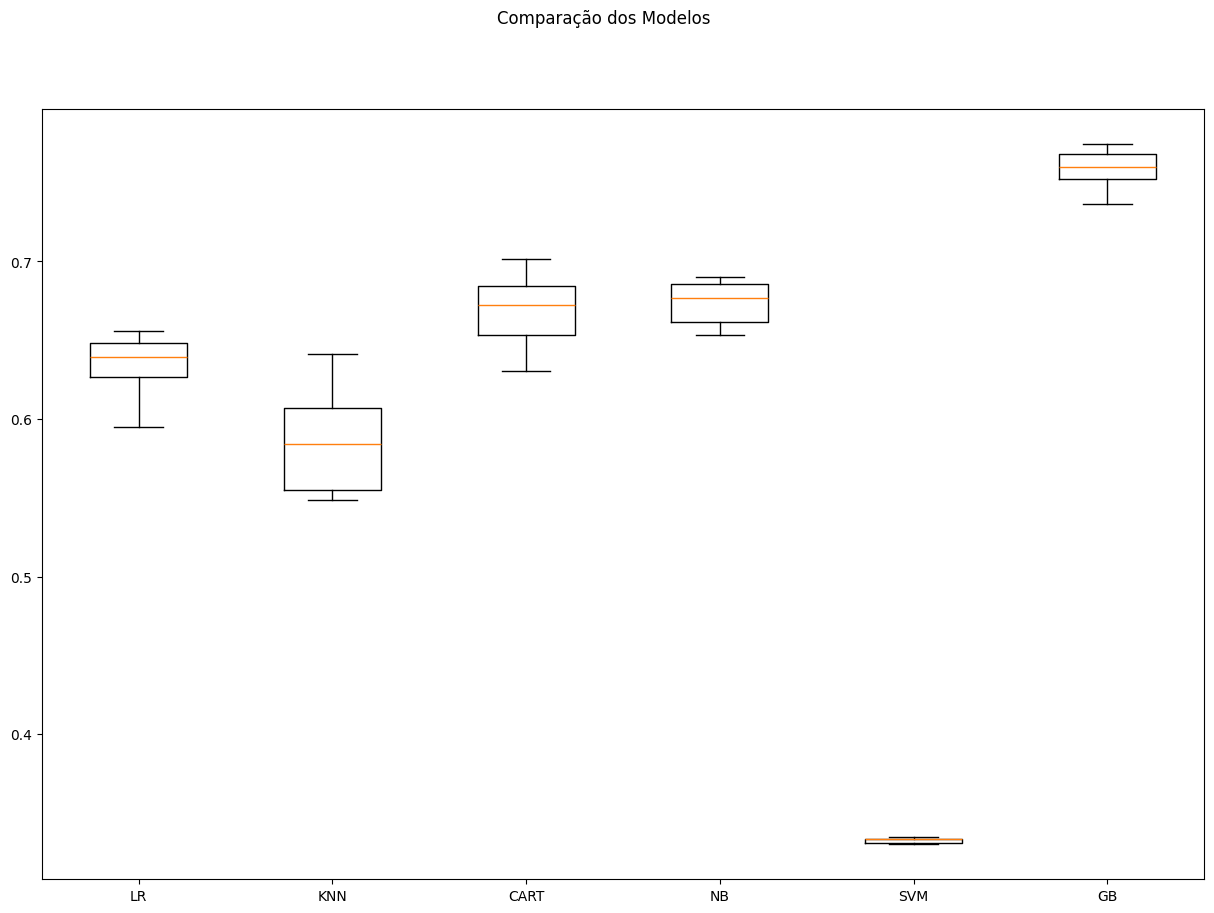

In [11]:
np.random.seed(seed)

# Lista que armazenará os modelos
models = []
num_trees = 100
max_features = "sqrt"

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200))) 
models.append(('KNN', KNeighborsClassifier())) 
models.append(('CART', DecisionTreeClassifier())) 
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))


# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos (treinamento)
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10)) 
fig.suptitle('Comparação dos Modelos') 
ax = fig.add_subplot(111) 
plt.boxplot(results) 
ax.set_xticklabels(names) 
plt.show()

## Desbalanceamento de Classes
O conjunto de dados apresenta uma distribuição desbalanceada entre as classes-alvo Graduate, Dropout e Enrolled, o que pode introduzir viés no processo de aprendizado dos modelos. Em cenários com desbalanceamento, classificadores tendem a favorecer a classe majoritária, comprometendo métricas como recall e F1-score nas classes minoritárias. Para mitigar esse efeito, será aplicada a técnica SMOTE (Synthetic Minority Oversampling Technique), que gera amostras sintéticas para as classes sub-representadas com base na interpolação entre instâncias existentes.

## Distribuição antes de realizar SMOTE

Graduate    2209

Dropout     1421

Enrolled     794


LR: 0.6734 (+/- 0.0181)
KNN: 0.5445 (+/- 0.0271)
CART: 0.6789 (+/- 0.0198)
NB: 0.6808 (+/- 0.0256)
SVM: 0.2786 (+/- 0.1111)
GB: 0.7614 (+/- 0.0144)


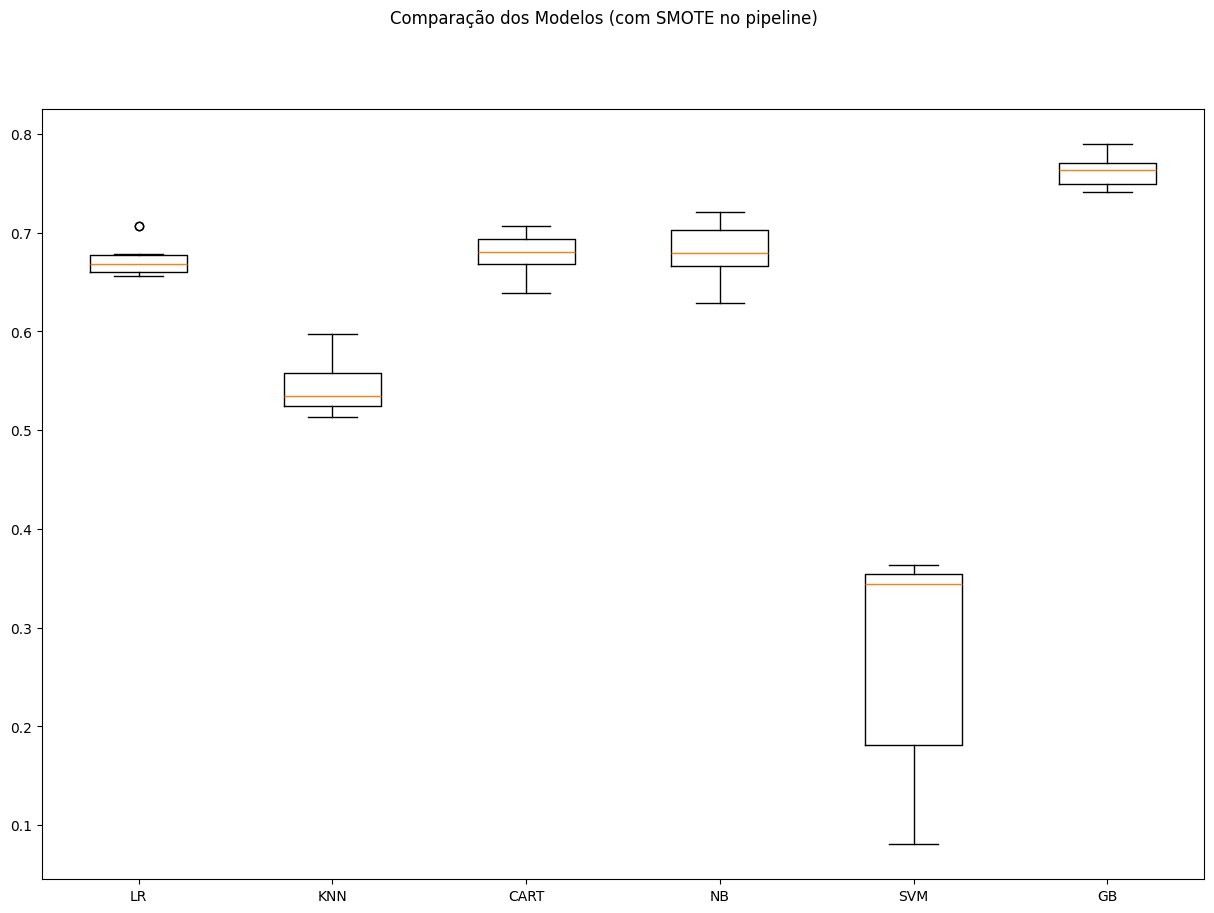

In [13]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

base_models = []
num_trees = 100

base_models.append(('LR',   LogisticRegression(max_iter=200)))
base_models.append(('KNN',  KNeighborsClassifier()))
base_models.append(('CART', DecisionTreeClassifier()))
base_models.append(('NB',   GaussianNB()))
base_models.append(('SVM',  SVC()))
base_models.append(('GB',   GradientBoostingClassifier(n_estimators=num_trees)))

smote_results = []
names = []

# Aplicaçao do SMOTE
for name, model in base_models:
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=seed)),
        ('model', model)
    ])
    smote_cv_results = cross_val_score(
        pipeline, X_train, y_train, cv=kfold, scoring=scoring
    )
    smote_results.append(smote_cv_results)
    names.append(name)
    print(f"{name}: {smote_cv_results.mean():.4f} (+/- {smote_cv_results.std():.4f})")

# Boxplot
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Comparação dos Modelos (com SMOTE no pipeline)')
ax = fig.add_subplot(111)
plt.boxplot(smote_results)
ax.set_xticklabels(names)
plt.show()

# Tabela comparativa Antes e Depois

In [21]:
# listas vazias para armazenar médias
medias_original = []
medias_smote = []

for valor in results:
    medias_original.append(valor.mean())

for valor in smote_results:
    medias_smote.append(valor.mean())

tabela_comparativa = pd.DataFrame({
    'Modelo':        names,
    'Sem SMOTE':     medias_original,
    'Com SMOTE':     medias_smote,
})

# coluna com diferença
tabela_comparativa['Δ'] = tabela_comparativa['Com SMOTE'] - tabela_comparativa['Sem SMOTE']

tabela_comparativa = tabela_comparativa.round(4)
tabela_comparativa

,Modelo,Sem SMOTE,Com SMOTE,Δ
0,LR,0.6342,0.6734,0.0392
1,KNN,0.5847,0.5445,-0.0402
2,CART,0.6695,0.6789,0.0094
3,NB,0.6739,0.6808,0.0069
4,SVM,0.3326,0.2786,-0.0540
5,GB,0.7593,0.7614,0.0021


### Criação e avaliação de modelos: dados padronizados e normalizados
#### f1_weighted

LR-orig: 0.634 (0.019)
LR-padr: 0.743 (0.013)
LR-norm: 0.737 (0.015)
KNN-orig: 0.585 (0.030)
KNN-padr: 0.683 (0.016)
KNN-norm: 0.655 (0.019)
CART-orig: 0.670 (0.021)
CART-padr: 0.680 (0.021)
CART-norm: 0.675 (0.020)
NB-orig: 0.674 (0.013)
NB-padr: 0.670 (0.014)
NB-norm: 0.670 (0.014)
SVM-orig: 0.333 (0.002)
SVM-padr: 0.743 (0.014)
SVM-norm: 0.729 (0.015)
Bagging-orig: 0.755 (0.015)
Bagging-padr: 0.756 (0.015)
Bagging-norm: 0.756 (0.013)
RF-orig: 0.754 (0.020)
RF-padr: 0.755 (0.009)
RF-norm: 0.749 (0.011)
ET-orig: 0.753 (0.014)
ET-padr: 0.753 (0.014)
ET-norm: 0.752 (0.010)
Ada-orig: 0.740 (0.018)
Ada-padr: 0.740 (0.018)
Ada-norm: 0.740 (0.018)
GB-orig: 0.758 (0.012)
GB-padr: 0.758 (0.012)
GB-norm: 0.758 (0.012)
Voting-orig: 0.631 (0.016)
Voting-padr: 0.747 (0.010)
Voting-norm: 0.736 (0.017)
LR-orig: 0.634 (0.019)
LR-padr: 0.743 (0.013)
LR-norm: 0.737 (0.015)
KNN-orig: 0.585 (0.030)
KNN-padr: 0.683 (0.016)
KNN-norm: 0.655 (0.019)
CART-orig: 0.679 (0.020)
CART-padr: 0.670 (0.011)
CART-nor

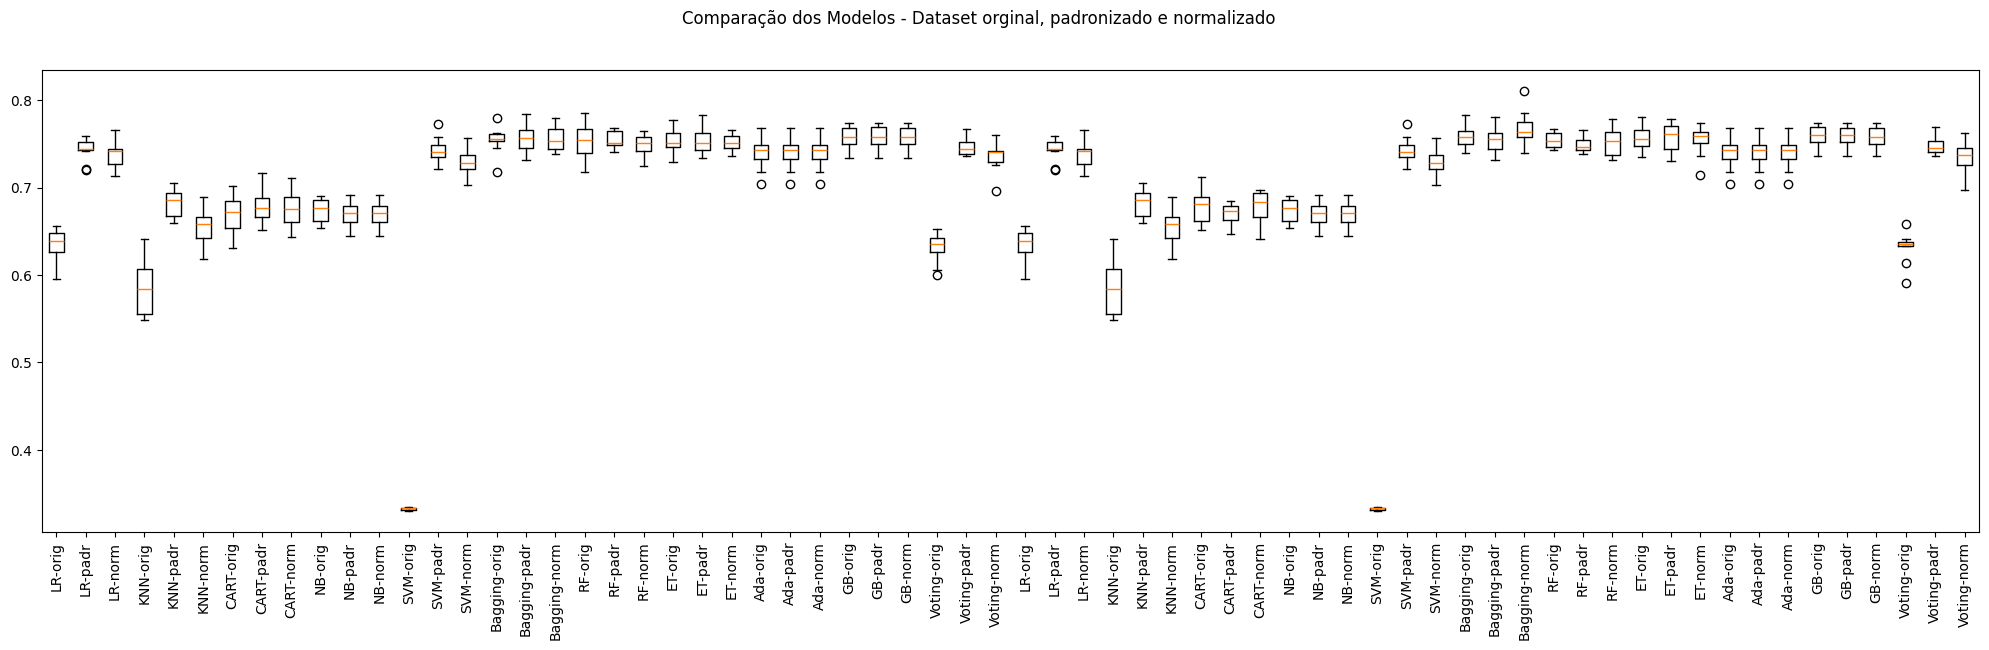

In [37]:
np.random.seed(seed) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200))) 
models.append(('KNN', KNeighborsClassifier())) 
models.append(('CART', DecisionTreeClassifier())) 
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 'sqrt'

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(estimators=bases, voting='hard')))

# Definindo os componentes do pipeline
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Criando pipelines para cada modelo
for name, model in models:
    pipelines.append((name + '-orig', Pipeline(steps=[(name, model)])))
    pipelines.append((name + '-padr', Pipeline(steps=[standard_scaler, (name, model)])))
    pipelines.append((name + '-norm', Pipeline(steps=[min_max_scaler, (name, model)])))


# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado') 
ax = fig.add_subplot(111) 
plt.boxplot(results) 
ax.set_xticklabels(names, rotation=90)
plt.show()


### Organizando os resultados em tabela

In [ ]:
# Nomes base de cada modelo (mesma ordem nas 3 listas)
model_names = ['LR', 'KNN', 'CART', 'NB', 'SVM', 'Bagging', 'RF', 'ET', 'Ada', 'GB', 'Voting']

# Fatia os resultados em 3 grupos de 11
n = len(model_names)  # 11
results_orig = results[0:n]
results_padr = results[n:2*n]
results_norm = results[2*n:3*n]

# Monta o DataFrame com média (desvio)
def formatar(r):
    return f"{np.mean(r):.4f} ({np.std(r):.4f})"

df_comparacao = pd.DataFrame({
    'Modelo':        model_names,
    'Original':      [formatar(r) for r in results_orig],
    'Padronizado':   [formatar(r) for r in results_padr],
    'Normalizado':   [formatar(r) for r in results_norm],
})

df_comparacao.set_index('Modelo', inplace=True)
print(df_comparacao.to_string())

### Learning Curve
O quanto cada modelo pode ser melhorado com fine tunning?

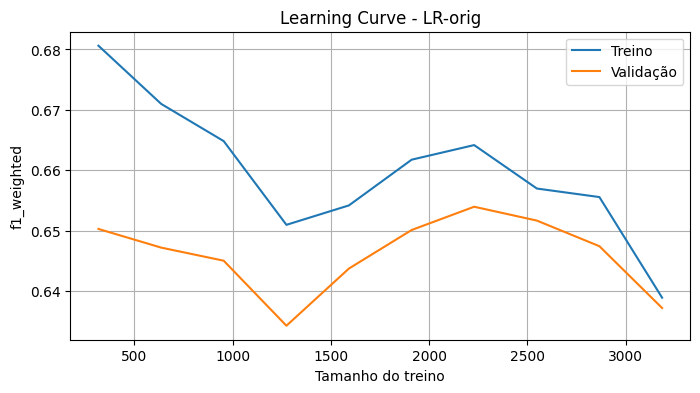

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

for name, model in pipelines:
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train, y_train,
        cv=kfold,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    plt.figure(figsize=(8, 4))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Treino')
    plt.plot(train_sizes, val_scores.mean(axis=1), label='Validação')
    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Tamanho do treino')
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.show()

    break

# Grid Search

## Todos os modelos - rodar de novo

In [ ]:
print(pipelines)
# print(results)
# print(names)

In [49]:
# Definindo os parâmetros para GridSearchCV
param_grids = {
    'LR': {
        'LR__C': [0.01, 0.1, 1, 10, 100],
        'LR__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'KNN__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
        'KNN__metric': ["euclidean", "manhattan", "minkowski"]
    },
    'CART': {
        'CART__max_depth': [None, 10, 20, 30, 40, 50],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'SVM': [
        {
            'SVM__kernel': ['linear'],
            'SVM__C': [0.1, 1, 10, 100]
        },
        {
            'SVM__kernel': ['rbf'],
            'SVM__C': [0.1, 1, 10, 100],
            'SVM__gamma': [1, 0.1, 0.01, 0.001]
        }
    ],
    'RF': {
        'RF__n_estimators': [10, 50, 100, 200],
        'RF__max_features': ['sqrt', 'log2'],
        'RF__max_depth': [None, 10, 20, 30],
        'RF__min_samples_split': [2, 5, 10],
        'RF__min_samples_leaf': [1, 2, 4]
    },
    'ET': {
        'ET__n_estimators': [10, 50, 100, 200],
        'ET__max_features': ['sqrt', 'log2'],
        'ET__max_depth': [None, 10, 20, 30],
        'ET__min_samples_split': [2, 5, 10],
        'ET__min_samples_leaf': [1, 2, 4]
    },
    'Ada': {
        'Ada__n_estimators': [10, 50, 100, 200],
        'Ada__learning_rate': [0.01, 0.1, 1, 10]
    },
    'GB': {
        'GB__n_estimators': [10, 50, 100, 200],
        'GB__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'GB__max_depth': [3, 5, 7, 9]
    },
    'Voting': {
        # Para VotingClassifier, geralmente não há hiperparâmetros para ajustar diretamente
        # Ajustar os hiperparâmetros dos estimadores base individualmente se necessário
    }
}

# Parâmetros de cross-validation e scoring
scoring = 'f1_weighted'
kfold = 5

# Executando o GridSearchCV para cada pipeline
for name, pipeline in pipelines:
    if name.endswith('-orig'):
        continue
    model_type = name.split('-')[0]
    if model_type in param_grids:
        param_grid = param_grids[model_type]
    else:
        param_grid = {}  # Para modelos que não têm parâmetros definidos

    grid = GridSearchCV(
        estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold,
        n_jobs=-1,
        refit=False,
        )
    grid.fit(X_train, y_train)
    # Imprimindo a melhor configuração
    print("Modelo: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))
    

Modelo: LR-padr - Melhor: 0.744138 usando {'LR__C': 1, 'LR__solver': 'saga'}
Modelo: LR-norm - Melhor: 0.744289 usando {'LR__C': 10, 'LR__solver': 'saga'}
Modelo: KNN-padr - Melhor: 0.682657 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5}
Modelo: KNN-norm - Melhor: 0.660544 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5}
Modelo: CART-padr - Melhor: 0.718895 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 4, 'CART__min_samples_split': 10}
Modelo: CART-norm - Melhor: 0.719859 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 10}
Modelo: NB-padr - Melhor: 0.670177 usando {'NB__var_smoothing': 1e-09}
Modelo: NB-norm - Melhor: 0.670177 usando {'NB__var_smoothing': 1e-09}
Modelo: SVM-padr - Melhor: 0.755893 usando {'SVM__C': 100, 'SVM__kernel': 'linear'}
Modelo: SVM-norm - Melhor: 0.754005 usando {'SVM__C': 100, 'SVM__kernel': 'linear'}
Modelo: Bagging-padr - Melhor: 0.760950 usando {}
Modelo: Bagging-norm - Melhor: 0.759032

## KNN

In [25]:
# Tuning do KNN

np.random.seed(seed) # definindo uma semente global para este bloco

pipelines = []

# Definindo os componentes do pipeline
knn = ('KNN', KNeighborsClassifier())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('knn-orig', Pipeline(steps=[knn])))
pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))

param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

# Prepara e executa o GridSearchCV
for name, model in pipelines:    
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_)) 

Sem tratamento de missings: knn-orig - Melhor: 0.633691 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 11}
Sem tratamento de missings: knn-padr - Melhor: 0.682657 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5}
Sem tratamento de missings: knn-norm - Melhor: 0.660544 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5}


## Grid Search - accuracy

In [50]:
# Definindo os parâmetros para GridSearchCV
param_grids = {
    'LR': {
        'LR__C': [0.01, 0.1, 1, 10, 100],
        'LR__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'KNN__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
        'KNN__metric': ["euclidean", "manhattan", "minkowski"]
    },
    'CART': {
        'CART__max_depth': [None, 10, 20, 30, 40, 50],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'SVM': [
        {
            'SVM__kernel': ['linear'],
            'SVM__C': [0.1, 1, 10, 100]
        },
        {
            'SVM__kernel': ['rbf'],
            'SVM__C': [0.1, 1, 10, 100],
            'SVM__gamma': [1, 0.1, 0.01, 0.001]
        }
    ],
    'RF': {
        'RF__n_estimators': [10, 50, 100, 200],
        'RF__max_features': ['sqrt', 'log2'],
        'RF__max_depth': [None, 10, 20, 30],
        'RF__min_samples_split': [2, 5, 10],
        'RF__min_samples_leaf': [1, 2, 4]
    },
    'ET': {
        'ET__n_estimators': [10, 50, 100, 200],
        'ET__max_features': ['sqrt', 'log2'],
        'ET__max_depth': [None, 10, 20, 30],
        'ET__min_samples_split': [2, 5, 10],
        'ET__min_samples_leaf': [1, 2, 4]
    },
    'Ada': {
        'Ada__n_estimators': [10, 50, 100, 200],
        'Ada__learning_rate': [0.01, 0.1, 1, 10]
    },
    'GB': {
        'GB__n_estimators': [10, 50, 100, 200],
        'GB__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'GB__max_depth': [3, 5, 7, 9]
    },
    'Voting': {
        # Para VotingClassifier, geralmente não há hiperparâmetros para ajustar diretamente
        # Ajustar os hiperparâmetros dos estimadores base individualmente se necessário
    }
}

# Parâmetros de cross-validation e scoring
scoring = 'accuracy'
kfold = 5

# Executando o GridSearchCV para cada pipeline
for name, pipeline in pipelines:
    if name.endswith('-orig'):
        continue
    model_type = name.split('-')[0]
    if model_type in param_grids:
        param_grid = param_grids[model_type]
    else:
        param_grid = {}  # Para modelos que não têm parâmetros definidos

    grid = GridSearchCV(
        estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold,
        n_jobs=-1,
        refit=False,
        )
    grid.fit(X_train, y_train)
    # Imprimindo a melhor configuração
    print("Modelo: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))
    

Modelo: LR-padr - Melhor: 0.761794 usando {'LR__C': 1, 'LR__solver': 'saga'}
Modelo: LR-norm - Melhor: 0.762359 usando {'LR__C': 10, 'LR__solver': 'saga'}
Modelo: KNN-padr - Melhor: 0.712632 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 15}
Modelo: KNN-norm - Melhor: 0.695112 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 17}
Modelo: CART-padr - Melhor: 0.723081 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 10}
Modelo: CART-norm - Melhor: 0.721670 usando {'CART__max_depth': 10, 'CART__min_samples_leaf': 4, 'CART__min_samples_split': 5}
Modelo: NB-padr - Melhor: 0.685227 usando {'NB__var_smoothing': 1e-09}
Modelo: NB-norm - Melhor: 0.685227 usando {'NB__var_smoothing': 1e-09}
Modelo: SVM-padr - Melhor: 0.769989 usando {'SVM__C': 10, 'SVM__kernel': 'linear'}
Modelo: SVM-norm - Melhor: 0.768575 usando {'SVM__C': 100, 'SVM__kernel': 'linear'}
Modelo: Bagging-padr - Melhor: 0.766879 usando {}
Modelo: Bagging-norm - Melhor: 0.762921

# Resultados Finais e Considerações - Escolhendo o melhor modelo
Modelo: GB-orig - Melhor: 0.761002 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 5, 'GB__n_estimators': 100}

Modelo: GB-orig - Melhor: 0.764279 usando {'GB__learning_rate': 0.2, 'GB__max_depth': 5, 'GB__n_estimators': 50}

Modelo: ET-orig - Melhor: 0.756381 usando {'ET__max_depth': None, 'ET__max_features': 'sqrt', 'ET__min_samples_leaf': 1, 'ET__min_samples_split': 2, 'ET__n_estimators': 200}

Modelo: SVM-padr - Melhor: 0.755893 usando {'SVM__C': 100, 'SVM__gamma': 1, 'SVM__kernel': 'linear'}

## teste 1
Modelo: GB-orig - Melhor: 0.761002 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 5, 'GB__n_estimators': 100}

In [ ]:
# Avaliação do modelo com o conjunto de testes
# Modelo: GB-orig - Melhor: 0.761002 usando {'GB__learning_rate': 0.1, 'GB__max_depth': 5, 'GB__n_estimators': 100}
from sklearn.metrics import classification_report


np.random.seed(seed)

model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7575617893524028
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.57      0.42      0.48       159
    Graduate       0.80      0.90      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



## Teste 2
Modelo: GB-orig - Melhor: 0.764279 usando {'GB__learning_rate': 0.2, 'GB__max_depth': 5, 'GB__n_estimators': 50}

In [51]:
np.random.seed(seed)

model = GradientBoostingClassifier(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=50
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7648772857683419
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.62      0.43      0.51       159
    Graduate       0.80      0.90      0.85       442

    accuracy                           0.77       885
   macro avg       0.74      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



## Teste 3
Modelo: ET-orig - Melhor: 0.756381 usando {'ET__max_depth': None, 'ET__max_features': 'sqrt', 'ET__min_samples_leaf': 1, 'ET__min_samples_split': 2, 'ET__n_estimators': 200}

In [52]:
np.random.seed(seed)


model = ExtraTreesClassifier(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200,
    max_features='sqrt')

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(f1_score(y_test, predictions, average='weighted'))
print(classification_report(y_test, predictions))

0.7653002253012949
              precision    recall  f1-score   support

     Dropout       0.83      0.77      0.80       284
    Enrolled       0.65      0.39      0.49       159
    Graduate       0.78      0.92      0.84       442

    accuracy                           0.78       885
   macro avg       0.75      0.69      0.71       885
weighted avg       0.77      0.78      0.77       885



## Teste 4
Modelo: SVM-padr - Melhor: 0.755893 usando {'SVM__C': 100, 'SVM__gamma': 1, 'SVM__kernel': 'linear'}

In [ ]:
np.random.seed(seed)


# standard_scaler = ('StandardScaler', StandardScaler())

    # pipelines.append((name + '-padr', Pipeline(steps=[standard_scaler, (name, model)])))

# Preparação do modelo
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)

model = SVC(
    C=100,
    gamma=1,
    kernel='linear'
)
model.fit(rescaledX, y_train)

# Estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test) # aplicação da normalização no conjunto de teste
predictions = model.predict(rescaledTestX)
print(f1_score(y_test, predictions, average='weighted'))



0.754649334639555


In [57]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

     Dropout       0.81      0.74      0.77       284
    Enrolled       0.57      0.40      0.47       159
    Graduate       0.79      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.70       885
weighted avg       0.75      0.77      0.75       885



# Salvando - fazer next

In [ ]:
# Salvando o modelo
model_filename = 'rf_diabetes_classifier.pkl'
with open("../models/"+model_filename, 'wb') as file:
    pickle.dump(model, file)

# Salvando o scaler
scaler_filename = 'minmax_scaler_diabetes.pkl'
with open("../scalers/"+scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
    
# Salvando o pipeline
pipeline_filename = 'rf_diabetes_pipeline.pkl'
with open("../pipelines/"+pipeline_filename, 'wb') as file:
    pickle.dump(pipeline, file)
    
# Salvando X_test e y_test
X_test_df = pd.DataFrame(X_test, columns=dataset.columns[:-1])
y_test_df = pd.DataFrame(y_test, columns=[dataset.columns[-1]])
X_test_df.to_csv("../data/X_test_dataset_diabetes.csv", index=False)
y_test_df.to_csv("../data/y_test_dataset_diabetes.csv", index=False)

# Simulando a aplicação do modelo em dados não vistos

In [ ]:
# Preparação do modelo com TODO o dataset
scaler = MinMaxScaler().fit(X) # ajuste do scaler com TODO o dataset
rescaledX = scaler.transform(X) # aplicação da normalização com TODO o dataset
model.fit(rescaledX, y)

In [ ]:
# Novos dados - não sabemos a classe!
data = {'preg':  [1, 9, 5],
        'plas': [90, 100, 110],
        'pres': [50, 60, 50],
        'skin': [30, 30, 30],
        'test': [100, 100, 100],
        'mass': [20.0, 30.0, 40.0],
        'pedi': [1.0, 2.0, 1.0],
        'age': [15, 40, 40],  
        }

atributos = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
entrada = pd.DataFrame(data, columns=atributos)

array_entrada = entrada.values
X_entrada = array_entrada[:,0:8].astype(float)

# Padronização nos dados de entrada usando o scaler utilizado em X
rescaledEntradaX = scaler.transform(X_entrada)
print(rescaledEntradaX)

In [ ]:
# Predição de classes dos dados de entrada
saidas = model.predict(rescaledEntradaX)
print(saidas)